In [114]:
#Import necessary libraries and load the data
import pandas as pd
import numpy as np
from datetime import datetime
from pathlib import Path

data_path = None
for base in (Path.cwd(), Path.cwd().parent):
    candidate = base / 'data' / 'raw' / 'listings.csv'
    if candidate.exists():
        data_path = candidate
        break

if data_path is None:
    raise FileNotFoundError("Could not find 'data/raw/listings.csv' from the current notebook location.")

df_listings = pd.read_csv(data_path)

C:\Users\USER\AppData\Local\Temp\ipykernel_19168\1721328806.py:17: DtypeWarning: Columns (0: license) have mixed types. Specify dtype option on import or set low_memory=False.
  df_listings = pd.read_csv(data_path)


In [115]:
#Remove unnecessary columns
columns_to_drop = ['id', 'host_name', 'license']
df_listings=df_listings.drop(columns=[col for col in columns_to_drop if col in df_listings.columns])

In [116]:
string_columns = ['name', 'neighbourhood', 'room_type']
for col in string_columns:
    if col in df_listings.columns:
        df_listings[col] = df_listings[col].astype(str).str.strip()

In [117]:
#Format date columns
df_listings['last_review'] = pd.to_datetime(df_listings['last_review'], errors='coerce')
print(f"Date range: {df_listings['last_review'].min()} to {df_listings['last_review'].max()}")

Date range: 2011-10-12 00:00:00 to 2022-12-05 00:00:00


In [118]:
# Handle missing values
# For price: remove rows with missing price
df_listings = df_listings[df_listings['price'].notna()]
# For reviews_per_month: fill missing with 0
df_listings['reviews_per_month'] = df_listings['reviews_per_month'].fillna(0)
# For minimum_nights: fill missing with median
df_listings['minimum_nights'] = df_listings['minimum_nights'].fillna(df_listings['minimum_nights'].median())

In [119]:
# Convert numeric columns to correct types
numeric_columns = ['minimum_nights', 'number_of_reviews', 'reviews_per_month']
for col in numeric_columns:
    if col in df_listings.columns:
        df_listings[col] = pd.to_numeric(df_listings[col], errors='coerce')

In [120]:
df_listings['price'] = pd.to_numeric(df_listings['price'].astype(str).str.replace(r'[\$,]', '', regex=True), errors='coerce')

In [121]:
#Remove ouliers in price (extreme prices)
df_listings = df_listings[df_listings['price'] <= 1000]
#Remove negative prices if any
df_listings = df_listings[df_listings['price'] > 0]

In [122]:
# Create new feature - That shows price categories in terms of ranges
def categorize_price(price):
    if price < 100:
        return 'Budget (<$100)'
    elif price < 200:
        return 'Moderate ($100-$200)'
    elif price < 350:
        return 'Expensive ($200-$350)'
    else:
        return 'Luxury (>$350)'
df_listings['price_category'] = df_listings['price'].apply(categorize_price)

In [123]:
#Checked cleaned data
print(df_listings.info())
print(df_listings.describe())
print(f"Missing values after cleaning:\n{df_listings.isnull().sum()}")

<class 'pandas.DataFrame'>
Index: 36970 entries, 0 to 37409
Data columns (total 72 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   listing_url                                   36970 non-null  str           
 1   scrape_id                                     36970 non-null  float64       
 2   last_scraped                                  36970 non-null  str           
 3   name                                          36956 non-null  str           
 4   description                                   36121 non-null  str           
 5   neighborhood_overview                         22180 non-null  str           
 6   picture_url                                   36970 non-null  str           
 7   host_id                                       36970 non-null  int64         
 8   host_url                                      36970 non-null  str           
 9   

In [124]:
from pathlib import Path

output_dir = base / 'data' / 'processed'
output_dir.mkdir(parents=True, exist_ok=True)
df_listings.to_csv(output_dir / 'cleaned_airbnb_data.csv', index=False)
print("✅ Cleaned data saved to data/processed/cleaned_airbnb_data.csv")

✅ Cleaned data saved to data/processed/cleaned_airbnb_data.csv


In [125]:
#Initial Data Exploration
for base in (Path.cwd(), Path.cwd().parent):
    candidate = base / 'data' / 'processed' /'cleaned_airbnb_data.csv'
    if candidate.exists():
        data_path = candidate
        break
df_listings = pd.read_csv(data_path)
print(f"✅ Loaded data from {data_path}")
df_listings.head()
df_listings.info()

✅ Loaded data from c:\Users\USER\Desktop\nyc-airbnb-market-explorer\data\processed\cleaned_airbnb_data.csv
<class 'pandas.DataFrame'>
RangeIndex: 36970 entries, 0 to 36969
Data columns (total 72 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   listing_url                                   36970 non-null  str    
 1   scrape_id                                     36970 non-null  float64
 2   last_scraped                                  36970 non-null  str    
 3   name                                          36956 non-null  str    
 4   description                                   36121 non-null  str    
 5   neighborhood_overview                         22180 non-null  str    
 6   picture_url                                   36970 non-null  str    
 7   host_id                                       36970 non-null  int64  
 8   host_url                                

In [126]:
# Summary statistics by borough
borough_stats = df_listings.groupby('neighbourhood_group_cleansed').agg({
    'price': ['mean', 'median', 'std', 'min', 'max'],
    'number_of_reviews': 'mean',
    'room_type': 'count'
}).round(2)

print(borough_stats)

                               price                               \
                                mean median     std   min     max   
neighbourhood_group_cleansed                                        
Bronx                         111.48   85.0   91.33  11.0  1000.0   
Brooklyn                      142.87  108.0  119.12  10.0  1000.0   
Manhattan                     214.87  165.0  166.91  10.0  1000.0   
Queens                        116.61   85.0  101.04  10.0   999.0   
Staten Island                 131.23  100.0  109.49  21.0   850.0   

                             number_of_reviews room_type  
                                          mean     count  
neighbourhood_group_cleansed                              
Bronx                                    28.69      1371  
Brooklyn                                 28.83     13891  
Manhattan                                22.86     15507  
Queens                                   29.35      5803  
Staten Island                     

In [127]:
import os

# 1. Directly overwrite the 7 multi-level data columns (excluding the Borough index)
borough_stats.columns = [
    'Price (Mean)', 'Price (Median)', 'Price (Std Dev)', 'Price (Min)', 'Price (Max)', 
    'Avg Reviews', 
    'Total Listings'
]

# 2. Convert to markdown but TELL it to include the Index, labeling it 'Borough'
markdown_table = borough_stats.to_markdown(index=True, tablefmt="github", headers=["Borough"] + list(borough_stats.columns) )

# 3. Formulate the Markdown document string
markdown_content = f"""# New York City Airbnb Market Analysis

## 2. Borough Analysis
Below is the statistical summary of Airbnb listings across the different NYC boroughs, detailing price variance, review engagement, and overall supply distribution:

{markdown_table}

### Key Takeaways:
* **Manhattan** maintains the highest average and median price tier, alongside the widest variance (Std Dev) in pricing.
* **Brooklyn** offers a highly competitive marketplace with robust listing volumes and strong review engagement.
* **Bronx, Queens, and Staten Island** present the most budget-friendly averages for travelers.
"""

# 4. Save the file right inside your 'src' folder (where we know it works perfectly!)
with open('borough_summary.md', 'w', encoding='utf-8') as f:
    f.write(markdown_content)

print("✅ Success! Your markdown file has been generated inside the src folder!")

✅ Success! Your markdown file has been generated inside the src folder!


In [128]:
# Average price by room type
room_type_price = df_listings.groupby('room_type')['price'].mean().sort_values(ascending=False)
print(room_type_price)

room_type
Hotel room         396.216561
Entire home/apt    218.705252
Private room        99.440571
Shared room         86.771930
Name: price, dtype: float64


In [129]:
# Get counts and percentages
counts = df_listings['room_type'].value_counts()
pcts = df_listings['room_type'].value_counts(normalize=True) * 100

for room, count in counts.items():
    print(f"* **{room}**: {count:,} listings ({pcts[room]:.1f}%)")

* **Entire home/apt**: 20,811 listings (56.3%)
* **Private room**: 15,489 listings (41.9%)
* **Shared room**: 513 listings (1.4%)
* **Hotel room**: 157 listings (0.4%)


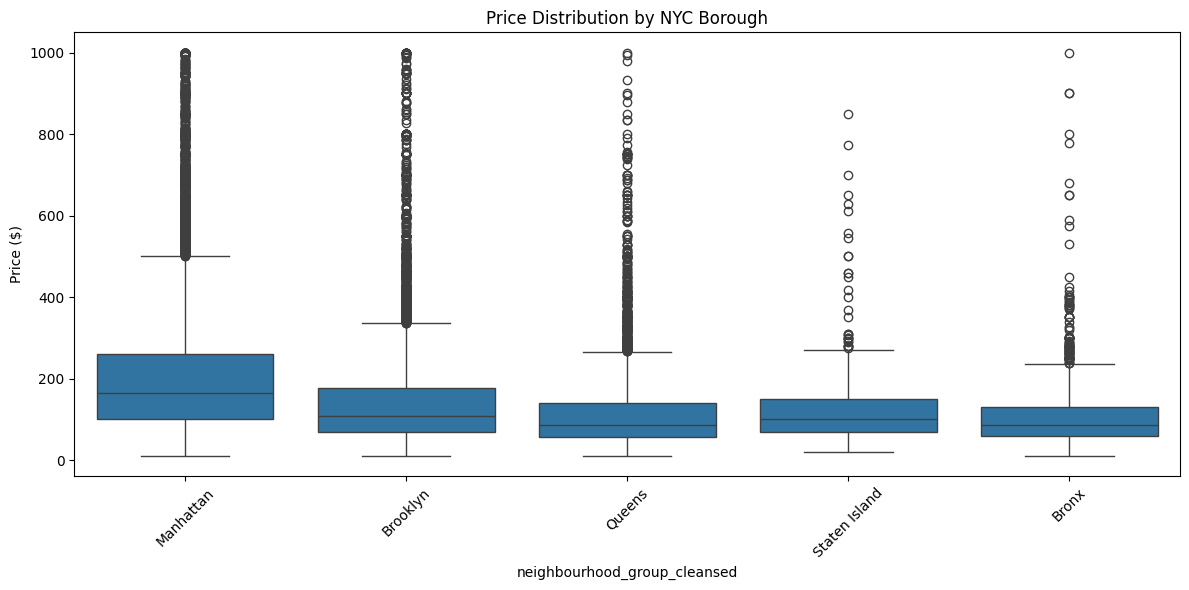

In [130]:
# Visualize the prices by borough
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_listings, x='neighbourhood_group_cleansed', y='price')
plt.title('Price Distribution by NYC Borough')
plt.xticks(rotation=45)
plt.ylabel('Price ($)')
plt.tight_layout()
output_dir = base / 'output'
output_dir.mkdir(exist_ok=True)
plt.savefig(output_dir / 'price_by_borough.png', dpi=300)
plt.show()

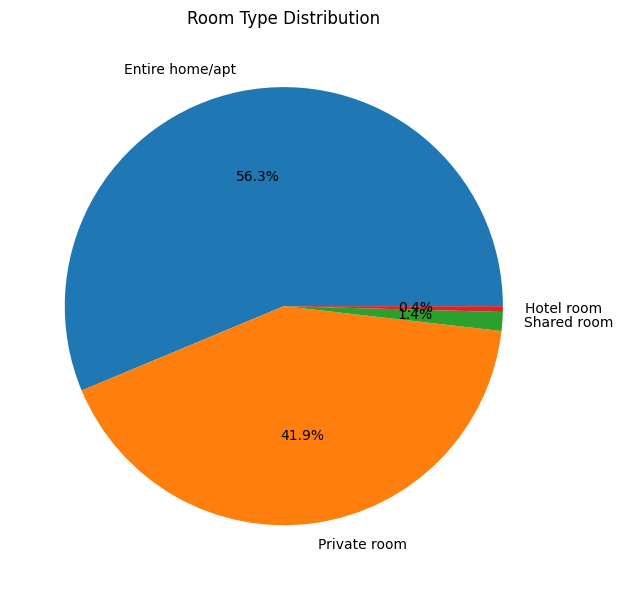

In [131]:
# Room type distribution
plt.figure(figsize=(8, 6))
df_listings['room_type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Room Type Distribution')
plt.ylabel('')
plt.tight_layout()
plt.savefig(output_dir / 'room_type_distribution.png', dpi=300)
plt.show()

In [132]:
# Top most expensive neighbourhoods
top_neighborhoods = df_listings.groupby('neighbourhood')['price'].mean().sort_values(ascending=False).head(10)
print("\nTop 10 Most Expensive Neighborhoods:")
print(top_neighborhoods)


Top 10 Most Expensive Neighborhoods:
neighbourhood
Atlantic Beach, New York, United States      595.500000
NEW YORK, New York, United States            541.866667
New York, NY, Argentina                      499.000000
Jamaica Estates, New York, United States     467.333333
Manhattan, New York, United States           454.500000
LONG ISLAND CITY, New York, United States    395.000000
Brooklyn , United States                     394.000000
Whitestone, New York, United States          364.000000
Far Rockaway , New York, United States       352.000000
Jamaica queens, New York, United States      350.000000
Name: price, dtype: float64


In [133]:
# Save the top neighbourhoods
top_neighborhoods_df = top_neighborhoods.reset_index()
top_neighborhoods_df.columns = ['neighbourhood', 'average_price']
output_dir.mkdir(parents=True, exist_ok=True)
top_neighborhoods_df.to_csv(output_dir / 'top_neighborhoods.csv', index=False)